# Solving a basic QUBO problem

A QUBO instance on $N$ variables consists in a symmetric matrix $Q$ of size $N\times N$. 

Solving a QUBO problem means to find the bitstring $z=(z_1,...,z_N)\in \{0, 1\}^N$ that minimizes the quantity

$$
f(z) = z^TQz= \sum_i Q_{ii} z_i + \sum_{i<j} Q_{ij} z_i z_j, \quad z_i \in \{0,1\}.
$$

### Problem Formulation in Rydberg Hamiltonian

To use a Rydberg Analog model, we need to map the QUBO problem onto the Rydberg Hamiltonian. 

This is achieved by identifying the binary variables with atomic occupations 
$$ 
z_i = n_i 
$$

where $ n_i \in \{0,1\} $ denotes whether atom $i$ is in the Rydberg state. 

The effective Hamiltonian in the classical (diagonal $\tilde{\Omega}=0$) limit of the driven Rydberg system can be written as

$$
H = - \sum_i \tilde{\delta}_i n_i + \sum_{i<j} \tilde{J}_{ij} n_i n_j,
$$

where $ \tilde{\delta} $ is the local detuning and $ J_{ij}=1/r_{ij}^6 $ is the interaction energy between atoms $i$ and $j$. By direct comparison, we obtain the mapping

$$
Q_{ii} \;\longleftrightarrow\; - \tilde{\delta}_i, \qquad Q_{ij} \;\longleftrightarrow\; \tilde{J}_{ij}.
$$

In this way, tuning the interaction strengths between atoms (e.g., via their spatial separation) we can match the QUBO coefficients, while adjusting $Q_{ii}$ maps to change the local detunings. Under this correspondence, the ground state of the Rydberg Hamiltonian minimizes $H$ and therefore encodes the optimal solution of the original QUBO problem.


## 1. Problem generation

Many real-world problems can be mapped to a QUBO problem, which means to create the matrix $Q$ that encodes the problem to solve. 

For the purpose of this tutorial we assume this task has already been performed and we are given the matrix $Q$, such as the one below:

In [1]:
import numpy as np

Q = np.array(
    [
        [-10.0, 19.7365809, 19.7365809, 5.42015853, 5.42015853],
        [19.7365809, -10.0, 20.67626392, 0.17675796, 0.85604541],
        [19.7365809, 20.67626392, -10.0, 0.85604541, 0.17675796],
        [5.42015853, 0.17675796, 0.85604541, -10.0, 0.32306662],
        [5.42015853, 0.85604541, 0.17675796, 0.32306662, -10.0],
    ]
)

QUBO problems are scale-invariant, and so we can work with the normalized matrix $\tilde{Q}=Q/\text{max}(Q)$ instead.

In [2]:
# Normalize QUBO matrix
Q = Q / Q.max()

#### *Classical Solutions*

Before showing how to solve this QUBO instance in the Rydberg analog model, we can compute the optimal solutions classically to compare. 

For that, we do a brute force cost calculation over all possible bitstrings, which scales exponentially with the number of variables. This is only possible because we are dealing with a small QUBO.

In [3]:
# Classical solution
bitstrings = np.array([np.binary_repr(i, len(Q)) for i in range(2 ** len(Q))])
bitstring_lists = np.array([np.array(list(b), dtype=int) for b in bitstrings])
Q_upper = np.triu(Q)
costs = np.array([z @ Q_upper @ z for z in bitstring_lists])
idx_sort = np.argsort(costs).tolist()

sorted_costs = costs[idx_sort]
sorted_bitstrings = bitstrings[idx_sort]

print("Two best solutions: ", sorted_bitstrings[:2])
print("Respective costs: ", sorted_costs[:2])

# We save the two best solutions for plotting
marked_bitstrings = sorted_bitstrings[:2]

Two best solutions:  ['00111' '01011']
Respective costs:  [-1.38536295 -1.38536295]


## 2. Problem embedding and Register creation

To embed the QUBO problem in the Rydberg analog model, we can directly use a matrix embedding technique like the `InteractionEmbedder`. 

The `InteractionEmbedder` maps a **matrix** to a **graph with node coordinates**, from which we can directly instantiate a qubit register later.

In [4]:
from qoolqit.embedding import InteractionEmbedder

embedder = InteractionEmbedder()
embedded_graph = embedder.embed(Q)

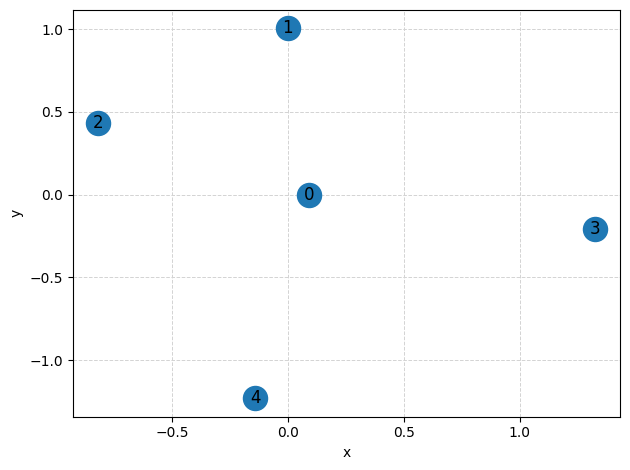

In [5]:
# Create the register
from qoolqit import Register

register = Register.from_graph(embedded_graph)
embedded_graph.draw()

You can read more about it in the [available embedders contents page](../fundamentals/embedding.md#matrix-embedding).


## 3. Drive definition

To solve this problem we define an **annealing protocol**. To define it we have to specify the annealing parameters.

#### *Intensity of Detuning and Amplitude*
Detuning $\tilde{\delta}$:
- $\tilde{\delta}(t=0)<0$. We have to start from a negative value of the detuning (compatible with the initial state $\ket{0}^{\otimes N}$)
- $\tilde{\delta}(t=T)=-\mathrm{diag}(Q)$. The final value of the detuning is chosen to match the diagonal part of the QUBO.

Amplitude $\tilde{\Omega}$:
- $\max{\tilde{\Omega}}=\mathrm{median}(\mathrm{off\_diag\_Q})$. 

NOTE: The value of $\tilde{\Omega}$ could be, in principle, optimized for each given QUBO but a good handwavy value is setting it as the median of the off-diagonal elements of the QUBO.

In [6]:
# Defining the annealing parameters
omega = np.median(Q[Q > 0])
delta_i = -1.0
delta_f = -np.diag(Q)[0]

#### *Time Duration*

We then define the shape and duration of the schedule.  In QoolQit, $\tilde{t}$ measures evolution time relative to the timescale on which interactions generate correlations. 

Roughly speaking, a time $\tilde{t} \sim 1$ is enough for nearest-neighbor sites to begin developing correlations. More generally, $\tilde{t} \sim n$ can be interpreted as the timescale on which correlations may have propagated over a distance of order $n$ lattice spacings.

This makes dimensionless time a convenient, geometry-independent way to describe how long the system evolves relative to its intrinsic interaction dynamics.

| Regime | Condition | Intuition |
|--------|-----------|-----------|
| Short time | $\tilde{t} \ll 1$ | Evolution is too brief for interactions to significantly build up correlations |
| Intermediate time | $\tilde{t} \sim 1$ | Interactions begin to visibly affect the dynamics; nearest-neighbor correlations can emerge |
| Long time | $\tilde{t} \gg 1$ | Correlations and many-body interaction effects have had time to spread across the system |


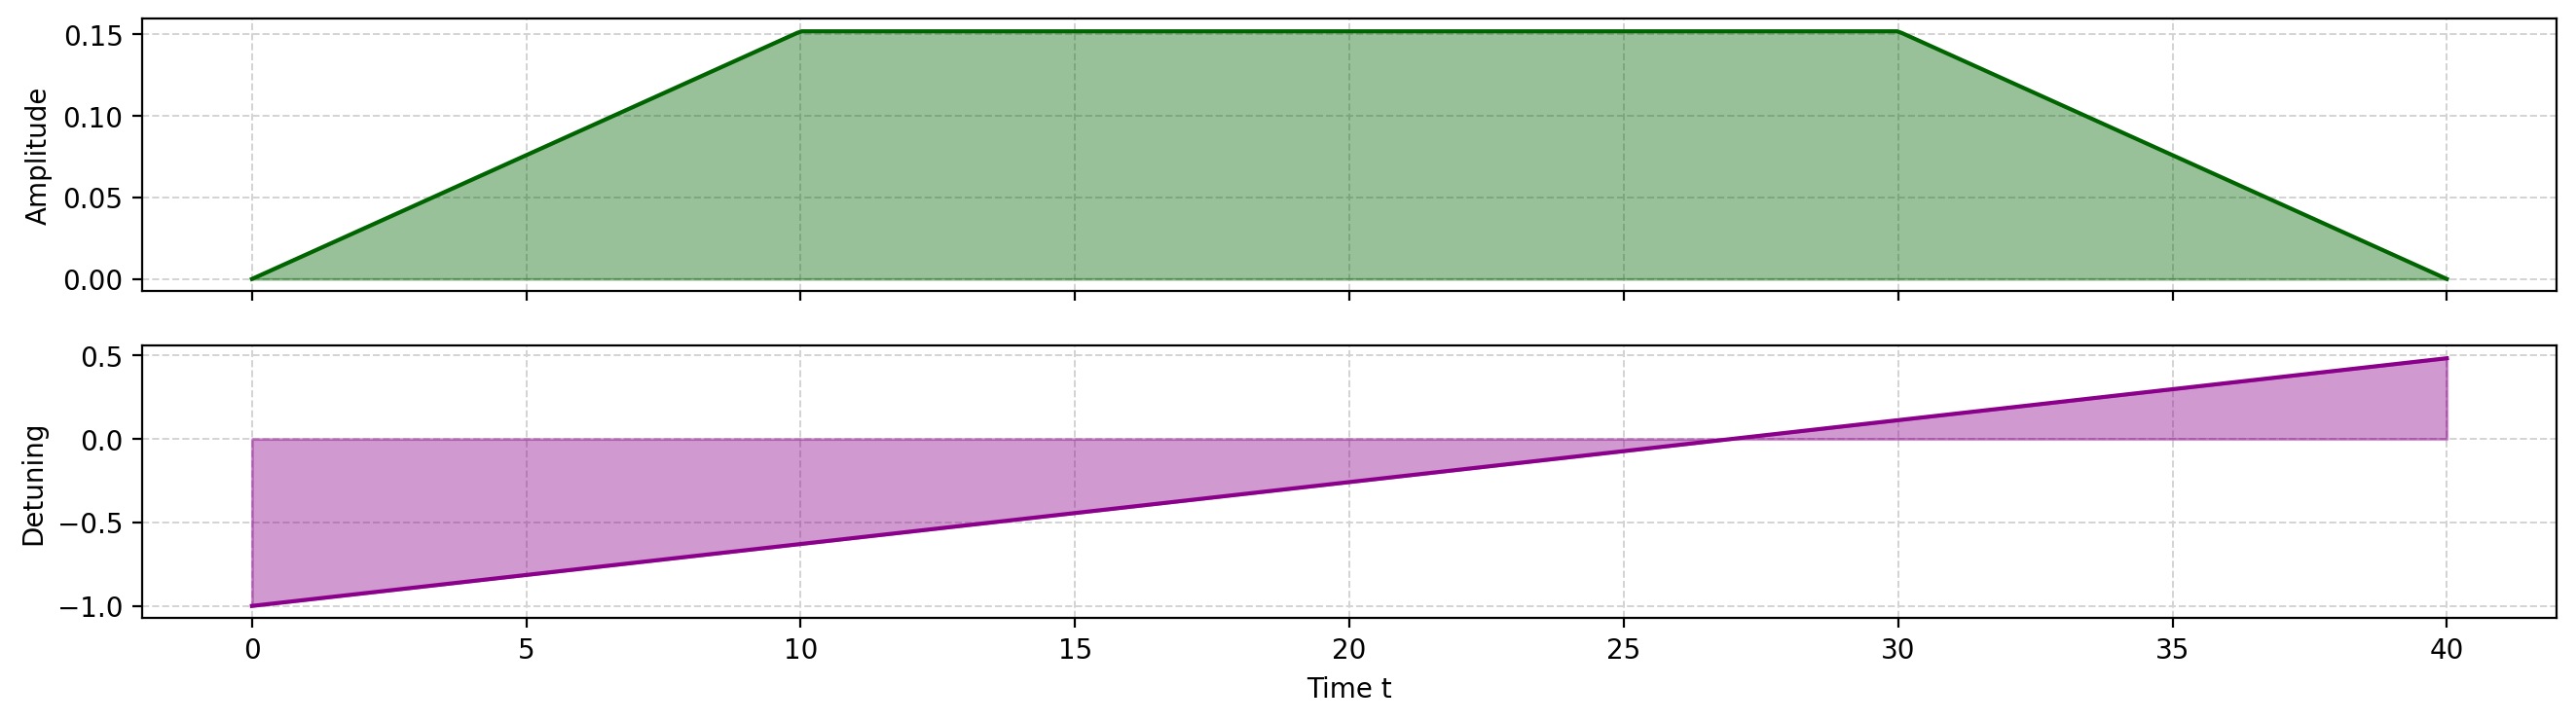

In [7]:
from qoolqit import Drive, PiecewiseLinear, QuantumProgram, Ramp, Register

# Defining the annealing schedule
T = 40
wf_amp = PiecewiseLinear([T / 4, T / 2, T / 4], [0.0, omega, omega, 0.0])
wf_det = Ramp(T, delta_i, delta_f)
drive = Drive(amplitude=wf_amp, detuning=wf_det)

# Writing the quantum program
program = QuantumProgram(register, drive)
program.draw()

## 4. Compilation of a Quantum Program

Before executing the quantum program, we need to compile it to a specific device real quantum device.

### Selecting a device
We pick the `FRESNEL`, a real Pasqal quantum device, whose specs can be fetched remotely from the `PasqalCloud` interface.
Then, we compile the program, and run it for a set number shots. 

In [8]:
from pulser_pasqal import PasqalCloud

from qoolqit import Device

fresnel_device = Device.from_connection(connection=PasqalCloud(), name="FRESNEL")

### Compiling a program to a device
We can compile the program as follows and visualize the compiled sequence that is the  one that will be used by the emulators or realized on the actual quantum device.

In [9]:
program.compile_to(device=fresnel_device)

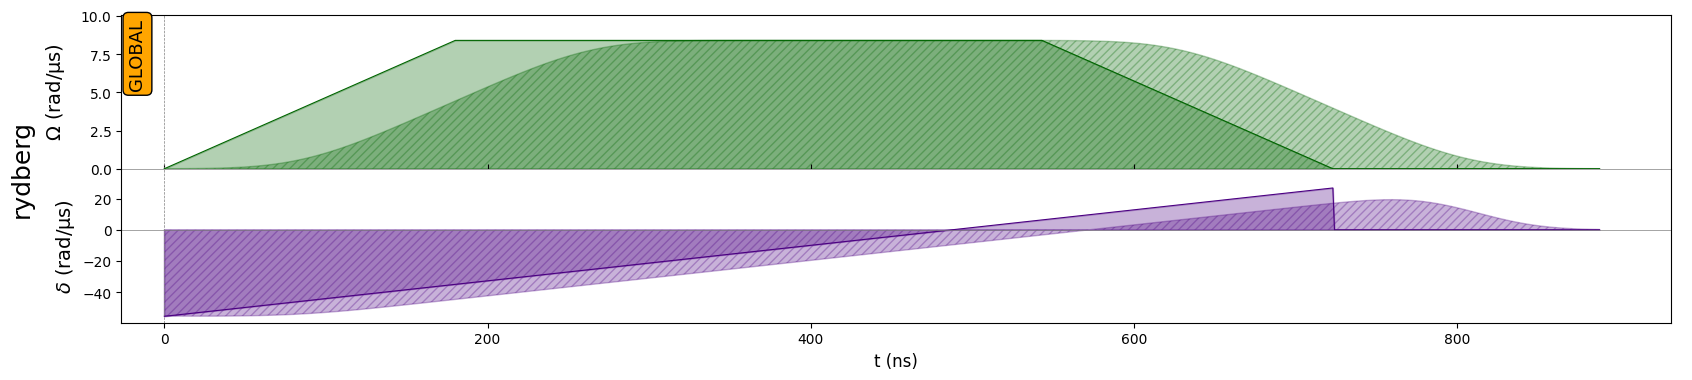

In [10]:
program.draw(compiled=True)

## 5. Execution of a Quantum Program

### Executing the program
As, anticipated, the program can now be executed on a real quantum device, or simulated using a local emulator.
For example, we can simulate the execution on a local emulator and inspect the results:

In [11]:
from qoolqit.execution import LocalEmulator

# instantiate a local emulator
emulator = LocalEmulator()

# execute the program on the local emulator
job = emulator.run(program)

# get the results
results = job.results()
counter = results.final_bitstrings
print(counter)

Counter({'00111': 180, '01011': 157, '10000': 95, '01001': 89, '01010': 84, '00110': 83, '00101': 71, '10001': 56, '10010': 53, '00100': 42, '01000': 35, '00011': 29, '10011': 18, '00010': 6, '00001': 2})


And finally we plot a histogram of the sampled bitstrings.

In [12]:
from collections import Counter

import matplotlib.pyplot as plt


def plot_distribution(counter, solutions, bins=10):
    counter = Counter(counter)
    counter = dict(counter.most_common(bins))
    color = [
        "tab:green" if key in solutions.tolist() else "tab:blue" for key in counter
    ]
    fig, ax = plt.subplots()
    ax.set_xlabel("Bitstrings")
    ax.set_ylabel("Counts")
    ax.bar(
        range(len(counter)), counter.values(), color=color, tick_label=counter.keys()
    )

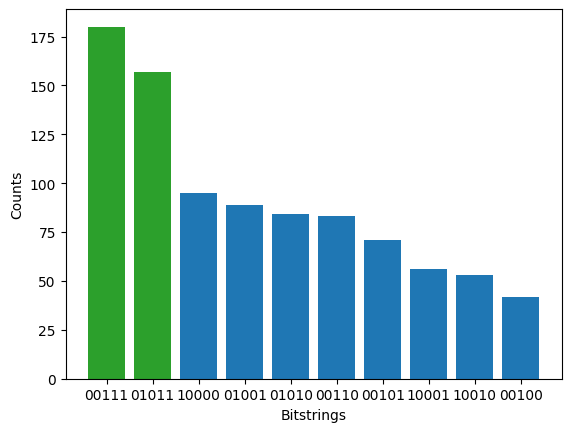

In [13]:
plot_distribution(counter, marked_bitstrings)

As we can see, the bitstrings we had marked as the optimal solutions of this QUBO problem were the ones sampled with the highest probability, meaning the the QUBO problem was successfully solved with the quantum program we defined.

## Advanced Compilation 

### Device maximum allowed duration

Optionally, at compilation, the drive duration can be rescaled to a fraction of the device's maximum allowed duration.
This option is useful in adiabatic protocols where one simply seek to minimize the time derivative of the drive's amplitude.

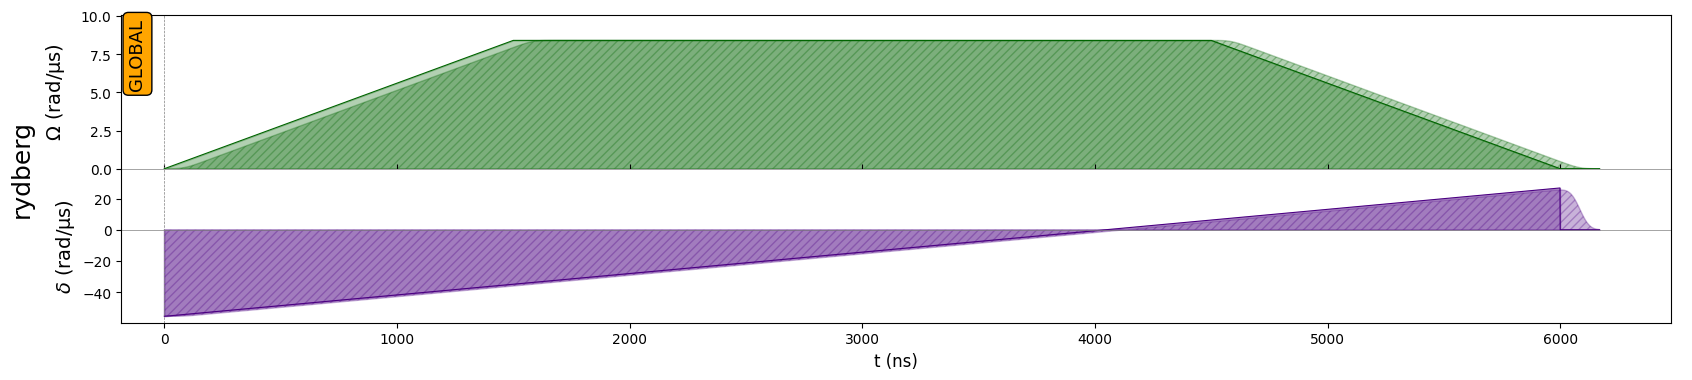

In [14]:
program.compile_to(device=fresnel_device, device_max_duration_ratio=1)
program.compiled_sequence.draw()

Concretely, we can see the beneficial effect of rescaling the drive duration on the simulation results:

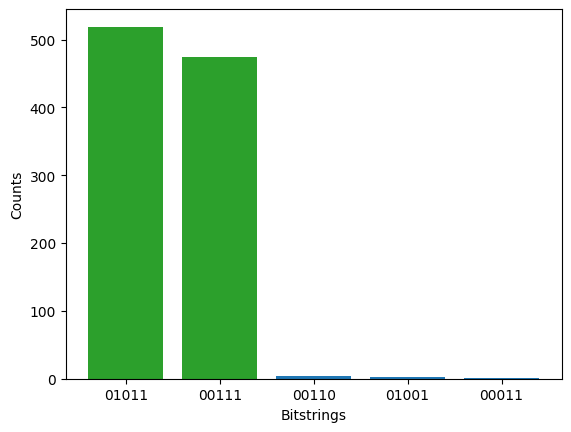

In [15]:
job = emulator.run(program)
results = job.results()
counter = results.final_bitstrings
plot_distribution(counter, marked_bitstrings)

Here the execution was relatively fast and easy, but for larger QUBO instances, or for QPU execution (which might have some queue), see the [Execution](https://docs.pasqal.com/qoolqit/qoolqitDoc/fundamentals/execution/execution/) section of the QoolQit documentation.